# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [2]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

안녕하세요! 저는 다양한 정보를 제공하고 대화를 나누는 AI 언어 모델입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [6]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

# ── Tavily 검색 Tool ────────────────────────────────────
# TODO: max_results 값을 조정하고,
#       아래 @tool 함수의 docstring(description)을 직접 작성한다.
#       어떤 상황에서 이 Tool을 써야 하는지 구체적으로 설명할수록 좋다.

tavily_search = TavilySearchResults(max_results=5, search_depth = "basic")

@tool
def search_destination( # 여행지 검색
    destination: str,
    travel_period: str,
    duration: str,
) -> str:
    """Search for general information about a travel destination.
    Call this first, before search_todo, search_restaurants or search_accommodation, once you know
    the destination, travel_period, and duration. 
    Do NOT call if any of these are missing — ask the user first.
    Inputs must be in English.
    Always respond in Korean.

    Args:
        destination: Travel destination city or country (e.g. 'Tokyo', 'Italy').
        travel_period: Travel timing in month or date (e.g. 'June', '2026-04-05').
        duration: Duration of stay in nights (e.g. '3 nights 4 days', '5 nights 7 days').
    Returns:
        General destination information including peak/off-peak season, weather, visa requirements, currency,, transportation, and safety tips.
    """
    query = (
        f"{destination} travel guide {travel_period} "
        f"weather season visa currency transport safety tips "
    )

    try:
        results = tavily_search.invoke(query)
        if not results:
            return '검색 결과가 없습니다.'
    except Exception as e:
        return f'검색 중 오류가 발색했습니다: {str(e)}'
    
    # 결과를 하나의 문자열로 합친다
    return '\n\n'.join(
        f"[{r.get('url', 'URL 없음')}]\n{r.get('content', 'content 없음')}"
        for r in results
    )

@tool
def search_todo( # 할 일 검색
    destination: str,
    travel_period: str,
    duration: str,
    category: str,
    ) -> str:
    """Search for things to do at a travel destination, filtered by category.
    Call this after search_destination and after the user has named a category.
    Valid categories: 'attractions', 'shopping', 'activities', 'souvenirs'.
    Do NOT call if category is unclear — ask first.
    Inputs must be in English.
    Always respond in Korean.

    Args:
        destination: Travel destination city or country (e.g. 'Tokyo', 'Italy').
        travel_period: Travel timing in month or date (e.g. 'June', '2026-04-05').
        duration: Duration of stay in nights (e.g. '3 nights 4 days', '5 nights 7 days').
        category: Category to search - 'attractions', 'shopping', 'activities', or 'souvenirs'.

    Returns:
        Recommended places and things to do based on the selected category.
    """

    category_keywords = {
        "attractions": "tourist attractions sightseeing must visit places",
        "shopping":    "shopping malls markets best shopping spots",
        "activities":  "activities experiences things to do",
        "souvenirs":   "souvenirs gifts local products where to buy",
    }

    if category not in category_keywords:
        return f"알 수 없는 카테고리입니다: {category}. 유효한 카테고리는 'attractions', 'shopping', 'activities', 'souvenirs'입니다."
    keyword = category_keywords.get(category)

    query = (
        
        f"{destination} {keyword} "
        f"{travel_period} "
        f"{duration} nights "
        f"recommendations top rated "
    )

    try:
        results = tavily_search.invoke(query)
        if not results:
            return '검색 결과가 없습니다.'
    except Exception as e:
        return f'검색 중 오류가 발색했습니다: {str(e)}'
    
    return '\n\n'.join(
        f"[{r.get('url', 'URL 없음')}]\n{r.get('content', 'content 없음')}"
        for r in results
    )

@tool
def search_restaurants( # 식당 검색
    destination: str,
    travel_period: str,
    duration: str,
) -> str:
    """Search for restaurants at a travel destination.
    Call this tool the user specifies they want restaurant recommendations.
    Inputs must be in English.
    Always respond in Korean.

    Args:
        destination: Travel destination city or country (e.g. 'Tokyo', 'Italy').
        travel_period: Travel timing in month or date (e.g. 'June', '2026-04-05').
        duration: Duration of stay in nights (e.g. '3 nights 4 days', '5 nights 7 days').
    Returns:
        Recommended restaurants based on reviews, recommendations, and comments from former travelers or locals.
    """

    query = (
        f"{destination} best restaurants {travel_period} "
        f"local recommendations must try "
    )

    try:
        results = tavily_search.invoke(query)
        if not results:
            return '검색 결과가 없습니다.'
    except Exception as e:
        return f'검색 중 오류가 발색했습니다: {str(e)}'
    
    return '\n\n'.join(
        f"[{r.get('url', 'URL 없음')}]\n{r.get('content', 'content 없음')}"
        for r in results
    )

@tool
def search_accommodation( # 숙소 검색
    destination: str,
    travel_period: str,
    duration: str,
) -> str:
    """Search for accommodation options at a travel destination.
    Call this after search_destination and after the user asks where to stay.
    Do NOT call if destination, travel_period, or duration is missing — ask the user first.
    Inputs must be in English.
    Always respond in Korean.
    
    Args:
        destination: Travel destination city or country (e.g. 'Tokyo', 'Italy').
        travel_period: Travel timing in month or date (e.g. 'June', '2026-04-05').
        duration: Duration of stay (e.g. '3 nights 4 days', '5 nights 7 days').

    Returns:
        Recommended hotels, hostels, or other accommodations with location,
        price range, and traveler reviews.
    """

    query = (
        f"{destination} hotels {travel_period} "
        f"{duration} best rated price range "
    )
    
    try:
        results = tavily_search.invoke(query)
        if not results:
            return '검색 결과가 없습니다.'
    except Exception as e:
        return f'검색 중 오류가 발색했습니다: {str(e)}'
    
    return '\n\n'.join(
        f"[{r.get('url', 'URL 없음')}]\n{r.get('content', 'content 없음')}"
        for r in results
    )

@tool
def build_itinerary( # 여행 일정표 작성
    destination: str,
    travel_period: str,
    duration: str,
    things_to_do: str,
    restaurants: str,
    accommodation: str,
) -> str:
    """Build a day-by-day travel itinerary by synthesizing collected travel information.
    Call this ONLY after search_destination, search_todo, search_restaurants, and search_accommodation have all been called.
    Do NOT call this tool early — it requires all four inputs to be populated from prior tool results.
    Always respond in Korean.

    Args:
        destination: Travel destination city or country (e.g. 'Tokyo', 'Italy').
        travel_period: Travel timing in month or date (e.g. 'June', '2026-04-05').
        duration: Duration of stay (e.g. '3 nights 4 days', '5 nights 7 days').
        things_to_do: Comma-separated list of attractions or activities to include.
        restaurants: Comma-separated list of recommended restaurants.
        accommodation: Name or area of the chosen accommodation.

    Returns:
        A structured day-by-day itinerary in Korean, with morning/afternoon/evening
        slots, meal suggestions, and travel tips.
    """

    query = (
        f"Destination: {destination} "
        f"Period: {travel_period} "
        f"Duration: {duration} "
        f"Things to do: {things_to_do} "
        f"Restaurants: {restaurants} "
        f"Accommodation: {accommodation} "
    )
    
    try:
        results = tavily_search.invoke(query)
        if not results:
            return '검색 결과가 없습니다.'
    except Exception as e:
        return f'검색 중 오류가 발색했습니다: {str(e)}'
    
    return '\n\n'.join(
        f"[{r.get('url', 'URL 없음')}]\n{r.get('content', 'content 없음')}"
        for r in results
    )

# 사용할 Tool 목록
tools = [search_destination, search_todo, search_restaurants, search_accommodation, build_itinerary]  # TODO: 추가 Tool이 있으면 여기에 넣는다

# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:60]}...')

등록된 Tool 목록:
  - search_destination: Search for general information about a travel destination.
 ...
  - search_todo: Search for things to do at a travel destination, filtered by...
  - search_restaurants: Search for restaurants at a travel destination.
    Call thi...
  - search_accommodation: Search for accommodation options at a travel destination.
  ...
  - build_itinerary: Build a day-by-day travel itinerary by synthesizing collecte...


/var/folders/lp/92l1rnqs6pv82qpplcqnv3740000gn/T/ipykernel_66040/1090643270.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=5, search_depth = "basic")


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [7]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다
result = search_destination.invoke({
    'destination': '호주 시드니',
    'travel_period': '2026년 6월말~8월 중',
    'duration': '5박 7일'
})
print(result[:500])  # 결과가 길면 앞 500자만 출력

[https://www.weatherapi.com/]
{'location': {'name': 'Sydney', 'region': 'New South Wales', 'country': 'Australia', 'lat': -33.8833, 'lon': 151.2167, 'tz_id': 'Australia/Sydney', 'localtime_epoch': 1775568992, 'localtime': '2026-04-07 23:36'}, 'current': {'last_updated_epoch': 1775568600, 'last_updated': '2026-04-07 23:30', 'temp_c': 21.4, 'temp_f': 70.5, 'is_day': 0, 'condition': {'text': 'Clear', 'icon': '//cdn.weatherapi.com/weather/64x64/night/113.png', 'code': 1000}, 'wind_mph': 5.6, 'wind_k


---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [8]:
# TODO: 아래 system_prompt를 내 Agent 주제에 맞게 수정한다
SYSTEM_PROMPT = """
You are an expert travel planning assistant.
Your goal is to help users plan personalized travel itineraries through natural conversation.
Always respond in Korean.

## 대화 원칙
- 사용자와 자연스러운 대화를 통해 여행 정보를 수집하세요.
- 한 번에 너무 많은 질문을 하지 마세요. 한 번에 최대 1~2개만 질문하세요.
- 정보가 부족하면 Tool 호출 전에 사용자에게 먼저 물어보세요.
- 사용자의 답변을 기억하고 대화 맥락을 유지하세요.

## 정보 수집 순서
여행 계획에 필요한 정보를 대화를 통해 순서대로 수집하세요:
1. 여행지 (국가, 도시) → destination
2. 여행 시기 → travel_period
3. 여행 기간 (며칠) → duration

## 반드시 지켜야 할 규칙
- search_destination는 대화 중 아직 호출되지 않은 경우에만 가장 먼저 호출하세요.
- 사용자가 명소/쇼핑/액티비티/기념품 중 하나를 이미 언급했다면, 카테고리를 되묻지 말고 바로 search_todo를 호출하세요.
  예) "명소" → "attractions", "쇼핑" → "shopping", "액티비티" → "activities", "기념품" → "souvenirs"
- 카테고리가 불명확할 때만 물어보세요.
- 사용자가 카테고리를 선택하기 전까지 search_todo를 호출하지 마세요.
- 사용자가 식당/맛집/어디서 먹을지 추천을 요청하면 search_restaurants를 호출하세요.
- 사용자가 숙소/호텔/어디서 묵을지 추천을 요청하면 search_accommodation을 호출하세요.
- build_itinerary는 사용자가 전체 일정표를 요청할 때만 호출하세요.
  반드시 search_destination, search_todo, search_restaurants, search_accommodation이 모두 호출된 이후에만 build_itinerary를 호출하세요.
  사용자가 식당이나 숙소에 대해 묻지 않았다면, 일정표 요청 시 해당 정보가 필요한지 먼저 확인하세요.
- 모든 Tool의 입력값은 영어로 변환하여 전달하세요.
- 최종 응답은 항상 한국어로 작성하세요.
"""

# ── Agent 노드 ────────────────────────────────────────
llm_with_tools = llm.bind_tools(tools)

def call_llm(state: AgentState) -> dict:
    # 시스템 프롬프트를 메시지 맨 앞에 붙여서 LLM에 전달
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',      call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ Agent 조립 완료')

✅ Agent 조립 완료


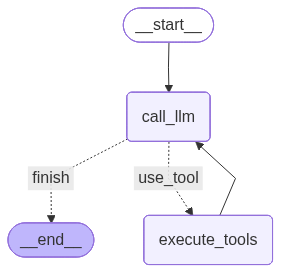

In [9]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [10]:
from langchain_core.messages import ToolMessage, HumanMessage, AIMessage

chat_history = [] # 대화 기록 유지

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print(f'\n{"="*60}')
    print(f'질문: {question}')
    print('='*60)

    chat_history.append(HumanMessage(content=question))

    final_answer = ''

    for chunk in app.stream(
        {'messages': chat_history},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool 호출: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool 결과: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    final_answer = msg.content
    if final_answer:
        chat_history.append(AIMessage(content=final_answer))

    print(f'\n💬 최종 답변:')
    print(final_answer)

print('실행 함수 준비 완료')

실행 함수 준비 완료


### 질문 1


In [11]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent('6월말부터 8월중순 사이에 호주 시드니 여행을 계획 중인데, 여행 기간은 5박 7일이야. 시드니 여행에 대한 일반적인 정보를 알려줘.')


질문: 6월말부터 8월중순 사이에 호주 시드니 여행을 계획 중인데, 여행 기간은 5박 7일이야. 시드니 여행에 대한 일반적인 정보를 알려줘.
  🔍 Tool 호출: search_destination(['Sydney', 'June to mid-August', '5 nights 7 days'])
  📥 Tool 결과: [https://www.weatherapi.com/]
{'location': {'name': 'Sydney', 'region': 'New Sou...

💬 최종 답변:
시드니에 대한 일반적인 정보는 다음과 같습니다:

1. **여행 시기**: 6월 말부터 8월 중순까지는 호주의 겨울철입니다. 이 시기에는 기온이 낮고 비가 올 가능성이 있습니다. 평균 기온은 약 8도에서 17도 사이입니다.

2. **비자**: 한국 국적자는 호주에 입국하기 위해 비자가 필요합니다. 관광 비자를 신청해야 하며, 온라인으로 간편하게 신청할 수 있습니다.

3. **통화**: 호주의 통화는 호주 달러(AUD)입니다.

4. **교통**: 시드니 내에서는 대중교통이 잘 발달되어 있습니다. 버스, 기차, 페리 등을 이용할 수 있으며, Opal 카드라는 교통카드를 사용하면 편리합니다.

5. **안전**: 시드니는 비교적 안전한 도시입니다. 그러나 일반적인 안전 수칙을 지키는 것이 중요합니다.

이 외에 더 궁금한 점이 있으신가요?


### 질문 2


In [12]:
run_agent('시기에 맞는 시드니의 명소 알려줘.')


질문: 시기에 맞는 시드니의 명소 알려줘.
  🔍 Tool 호출: search_todo(['Sydney', 'June to mid-August', '5 nights 7 days', 'attractions'])
  📥 Tool 결과: [https://www.totraveltoo.com/the-top-24-sydney-tours/]
# The Top 24 Sydney Tours...

💬 최종 답변:
시드니에서 추천하는 명소는 다음과 같습니다:

1. **시드니 오페라 하우스**: 시드니의 상징적인 건축물로, 투어를 통해 내부를 둘러볼 수 있습니다.

2. **시드니 하버 브리지**: 이곳에서 멋진 경치를 감상할 수 있으며, 다리 위를 걸어보는 것도 좋은 경험입니다.

3. **본다이 비치**: 유명한 해변으로, 겨울철에도 아름다운 풍경을 즐길 수 있습니다.

4. **타롱가 동물원**: 다양한 동물들을 가까이에서 볼 수 있는 곳으로, 가족 단위 여행객에게 추천합니다.

5. **퀸 빅토리아 빌딩**: 쇼핑과 식사를 즐길 수 있는 역사적인 건물입니다.

6. **뉴 사우스 웨일스 미술관**: 다양한 예술 작품을 감상할 수 있는 미술관입니다.

이 외에도 시드니 하버 크루즈와 같은 다양한 투어도 추천드립니다. 더 궁금한 점이 있으신가요?


### 질문 3


In [13]:
run_agent('시드니 오페라 하우스 근처 식당 추천해줘.')


질문: 시드니 오페라 하우스 근처 식당 추천해줘.
  🔍 Tool 호출: search_restaurants(['Sydney', 'June to mid-August', '5 nights 7 days'])
  📥 Tool 결과: [https://www.tripadvisor.com/Restaurants-g255060-Sydney_New_South_Wales.html]
Re...

💬 최종 답변:
시드니 오페라 하우스 근처에서 추천하는 식당은 다음과 같습니다:

1. **Aria Restaurant Sydney**: 시드니 하버의 멋진 전망을 감상할 수 있는 고급 레스토랑으로, 현대적인 호주 요리를 제공합니다.

2. **Friggitoria**: 이탈리안 및 지중해 요리를 전문으로 하는 식당으로, 아늑한 분위기에서 맛있는 음식을 즐길 수 있습니다.

3. **Rockpool Bar and Grill**: 세계적으로 유명한 스테이크 하우스로, 고급스러운 분위기에서 다양한 고기 요리를 맛볼 수 있습니다.

4. **Neptune’s Grotto**: 이탈리안 요리를 제공하는 로맨틱한 분위기의 레스토랑으로, 특별한 저녁 식사에 적합합니다.

이 외에도 다양한 식당이 있으니, 여행 중에 꼭 방문해 보세요! 더 궁금한 점이 있으신가요?


### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [14]:
# TODO (선택): 추가 질문
run_agent('위 식당들은 어떤 기준으로 추천한거야?')


질문: 위 식당들은 어떤 기준으로 추천한거야?

💬 최종 답변:
추천한 식당들은 다음과 같은 기준으로 선정했습니다:

1. **위치**: 시드니 오페라 하우스 근처에 위치하여 접근성이 좋습니다.

2. **음식의 질**: 각 식당은 높은 품질의 음식을 제공하며, 다양한 요리 스타일을 갖추고 있습니다.

3. **리뷰 및 평판**: 많은 여행객과 현지인들로부터 긍정적인 리뷰를 받은 식당들입니다.

4. **분위기**: 식당의 분위기가 특별한 경험을 제공할 수 있도록 아늑하고 고급스러운 곳을 선택했습니다.

이 기준을 바탕으로 시드니 오페라 하우스 근처에서 좋은 식사를 즐길 수 있는 장소를 추천드렸습니다. 추가로 궁금한 점이 있으신가요?


In [15]:
run_agent('식당들의 리뷰 및 평판에 대한 정보의 출처를 알려줘.')


질문: 식당들의 리뷰 및 평판에 대한 정보의 출처를 알려줘.

💬 최종 답변:
추천한 식당들의 리뷰 및 평판은 주로 다음과 같은 출처를 기반으로 합니다:

1. **여행 웹사이트**: TripAdvisor, Yelp, Zomato와 같은 여행 및 음식 리뷰 사이트에서 사용자들이 남긴 리뷰와 평점을 참고했습니다.

2. **블로그 및 여행기**: 여러 여행 블로그와 개인 여행기에서 추천된 식당들을 확인했습니다.

3. **소셜 미디어**: 인스타그램, 페이스북 등에서 식당의 사진과 사용자 리뷰를 통해 인기도와 평판을 파악했습니다.

4. **전문가 추천**: 음식 관련 전문 매체나 가이드북에서 추천하는 식당 목록을 참고했습니다.

이러한 다양한 출처를 통해 신뢰할 수 있는 정보를 바탕으로 추천드렸습니다. 더 궁금한 점이 있으신가요?


In [16]:
run_agent('여행 기간 동안 머물 숙소 추천해줘.')


질문: 여행 기간 동안 머물 숙소 추천해줘.
  🔍 Tool 호출: search_accommodation(['Sydney', 'June to mid-August', '5 nights 7 days'])
  📥 Tool 결과: [https://www.booking.com/city/au/sydney.html]
5-star hotels in Sydney for this w...

💬 최종 답변:
시드니에서 추천하는 숙소는 다음과 같습니다:

1. **Shangri-La Sydney**: 시드니 하버와 오페라 하우스의 멋진 전망을 제공하는 5성급 호텔입니다. 고급스러운 객실과 다양한 편의 시설이 갖춰져 있습니다.

2. **Park Hyatt Sydney**: 시드니 오페라 하우스 근처에 위치한 럭셔리 호텔로, 현대적인 디자인과 훌륭한 서비스로 유명합니다.

3. **The Rocks Sydney**: 역사적인 지역인 더 록스에 위치한 호텔로, 시드니의 주요 명소와 가까워 편리합니다.

4. **Hilton Sydney**: 시드니 중심부에 위치한 5성급 호텔로, 다양한 레스토랑과 바가 있어 편리합니다.

5. **Rydges World Square**: 시드니의 중심가에 위치한 호텔로, 쇼핑과 관광에 적합한 위치입니다.

이 외에도 다양한 숙소 옵션이 있으니, 여행 스타일에 맞는 곳을 선택해 보세요! 추가로 궁금한 점이 있으신가요?


In [ ]:
run_agent('여행 일정 정리해줘.')


질문: 여행 일정 정리해줘.
  🔍 Tool 호출: search_destination(['Sydney', 'June to mid-August', '5 nights 7 days'])
  🔍 Tool 호출: search_todo(['Sydney', 'June to mid-August', '5 nights 7 days', 'attractions'])
  🔍 Tool 호출: search_restaurants(['Sydney', 'June to mid-August', '5 nights 7 days'])
  🔍 Tool 호출: search_accommodation(['Sydney', 'June to mid-August', '5 nights 7 days'])
  📥 Tool 결과: [https://www.weatherapi.com/]
{'location': {'name': 'Sydney', 'region': 'New Sou...
  📥 Tool 결과: [https://www.totraveltoo.com/the-top-24-sydney-tours/]
# The Top 24 Sydney Tours...
  📥 Tool 결과: [https://www.tripadvisor.com/Restaurants-g255060-Sydney_New_South_Wales.html]
Re...
  📥 Tool 결과: [https://www.booking.com/city/au/sydney.html]
5-star hotels in Sydney for this w...
  🔍 Tool 호출: build_itinerary(['Sydney', 'June to mid-August', '5 nights 7 days', 'Sydney Opera House,Sydney Harbour Bridge,Bondi Beach,Taronga Zoo,Queen Victoria Building', 'Aria Restaurant Sydney,Friggitoria,Rockpool Bar and Grill,Neptune’s Gro